In [17]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [18]:
import pandas as pd
df = pd.read_excel("부산_구군별_연도별_방문자수_2021_2025_final.xlsx")

In [19]:
df

,연도,구군,현지인,외지인,외국인
0,2021,강서구,22610007.0,32449991.0,75584.91
1,2022,강서구,27916252.0,37013578.0,244725.17
2,2023,강서구,30254374.5,39971333.5,2704399.59
3,2024,강서구,30329530.0,41067383.0,4030042.58
4,2025,강서구,33443718.0,44556991.5,5571301.93
...,...,...,...,...,...
75,2021,해운대구,83514424.0,60211343.5,56267.99
76,2022,해운대구,87410834.0,66520097.0,237863.34
77,2023,해운대구,86758206.5,67603182.5,2004681.71
78,2024,해운대구,87120813.5,68279911.0,3059824.79


In [20]:
pivot_2025 = (
    df[df['연도'] == 2025]
    .pivot_table(
        index='구군',
        values=['현지인', '외지인', '외국인'],
        aggfunc='sum'
    )
    .reset_index()
)

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


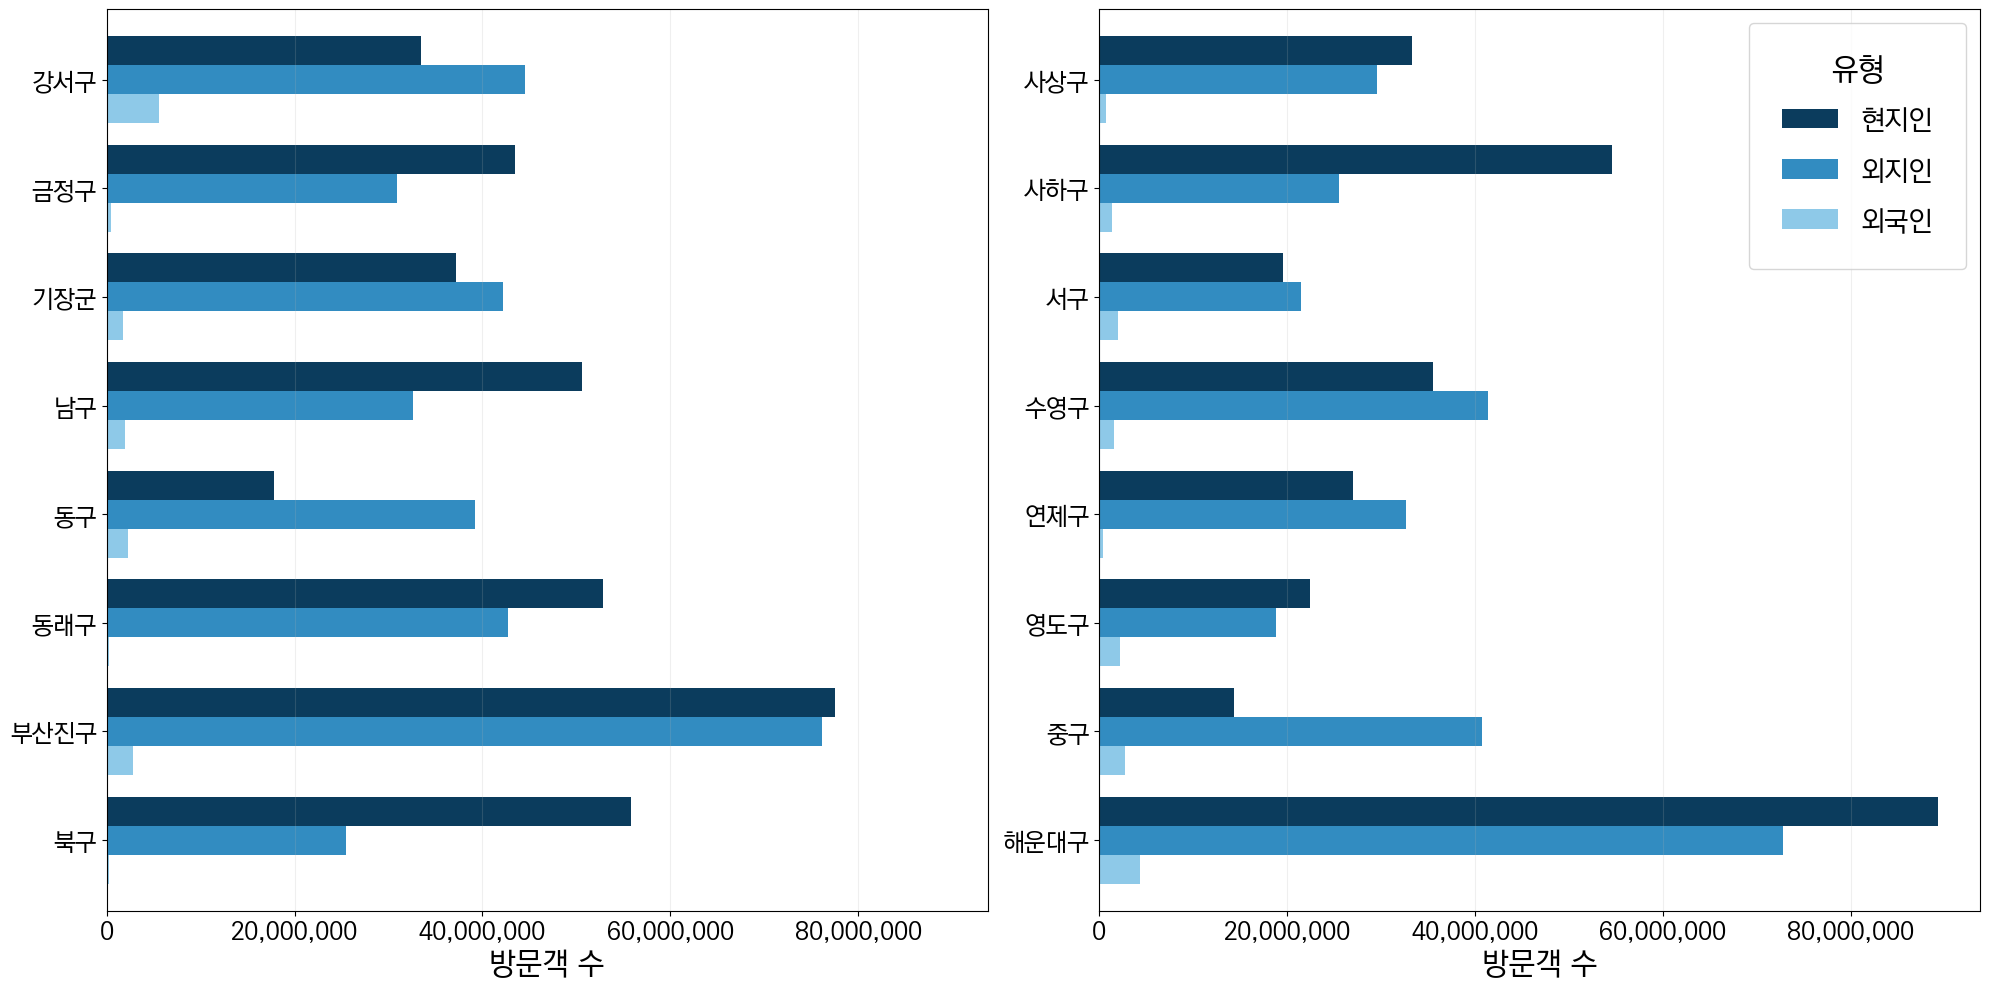

In [16]:
import matplotlib.pyplot as plt

# 가나다순 정렬
pivot_2025 = pivot_2025.sort_values('구군').reset_index(drop=True)

# 8개씩 분리
df1 = pivot_2025.iloc[:8]
df2 = pivot_2025.iloc[8:16]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 10),
    sharex=True
)

colors = ['#0B3C5D', '#328CC1', '#8EC9E8']

df1.plot(
    x='구군',
    y=['현지인', '외지인', '외국인'],
    kind='barh',
    ax=ax1,
    color=colors,
    width=0.8
)

df2.plot(
    x='구군',
    y=['현지인', '외지인', '외국인'],
    kind='barh',
    ax=ax2,
    color=colors,
    width=0.8
)

# 공통 설정
for ax in [ax1, ax2]:
    # x축 라벨 확대
    ax.set_xlabel('방문객 수', fontsize=22, fontweight='bold')
    ax.set_ylabel('')

    # x축 / y축 틱 라벨 확대
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )

    ax.grid(axis='x', alpha=0.2)
    ax.invert_yaxis()

# 왼쪽 범례 제거
ax1.get_legend().remove()

# 오른쪽 범례 확대
ax2.legend(
    title='유형',
    fontsize=20,
    title_fontsize=22,
    markerscale=1.5,
    borderpad=1.2,
    labelspacing=0.8
)

plt.tight_layout()
plt.savefig(
    '2025_구군별_방문객유형.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

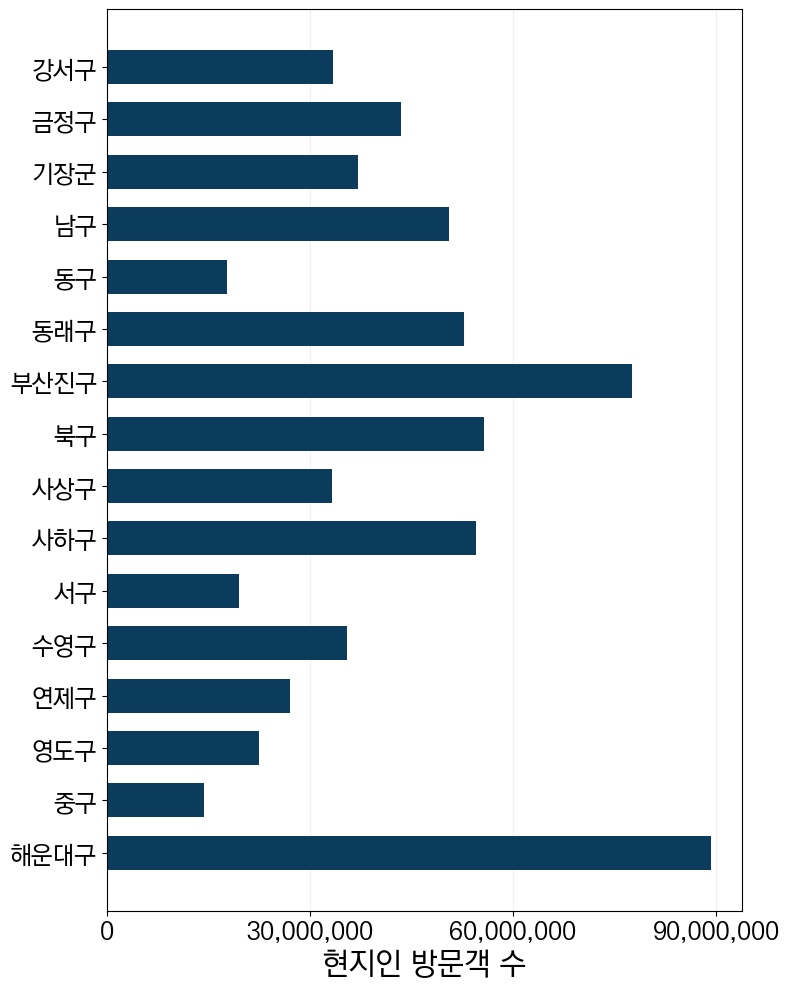

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# 2025년 데이터 + 구군 가나다순 정렬
local_2025 = (
    df[df['연도'] == 2025]
    .sort_values('구군')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    local_2025['구군'],
    local_2025['현지인'],
    color='#0B3C5D',
    height=0.65
)

# 가나다순 위 → 아래
ax.invert_yaxis()

# 축 설정
ax.set_xlabel('현지인 방문객 수', fontsize=22, fontweight='bold')
ax.set_ylabel('')

# 틱 라벨
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# 숫자 콤마 표시
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
# x축 틱 간격: 1천만
ax.xaxis.set_major_locator(MultipleLocator(30_000_000))

# 숫자 콤마 표시
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
# 보조선
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '2025_구군별_현지인.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

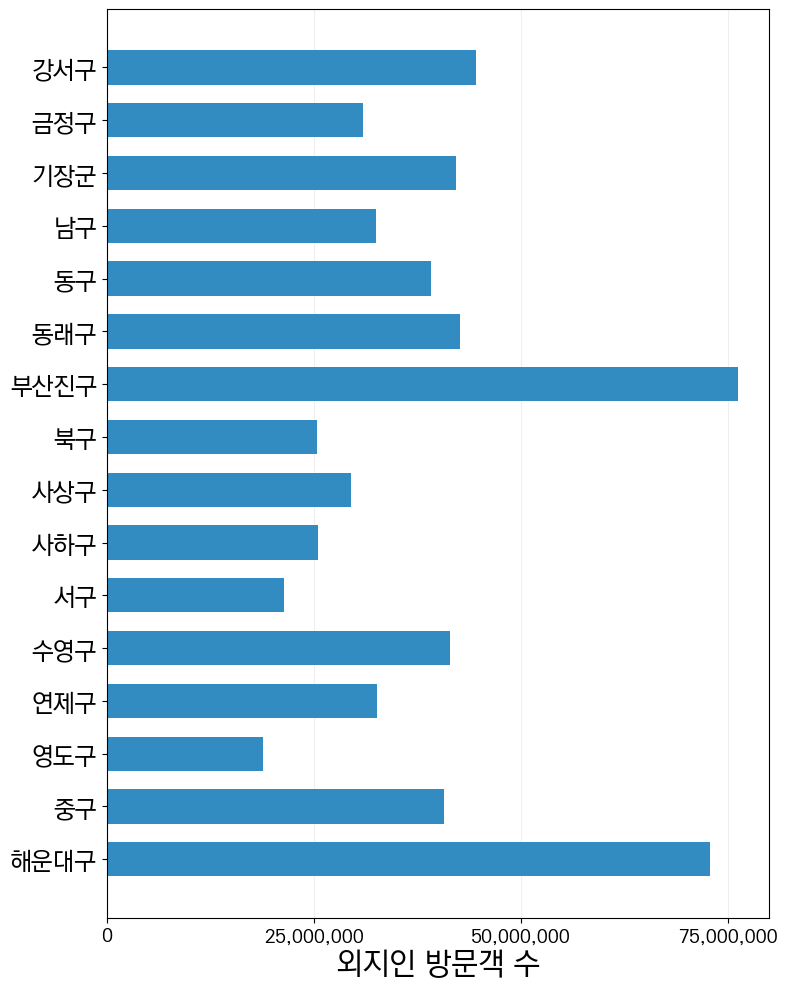

In [56]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    local_2025['구군'],
    local_2025['외지인'],
    color='#328CC1',
    height=0.65
)

ax.invert_yaxis()

ax.set_xlabel('외지인 방문객 수', fontsize=22, fontweight='bold')
ax.set_ylabel('')

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=18)

# x축 틱 간격: 2,500만
ax.xaxis.set_major_locator(
    MultipleLocator(25_000_000)
)

# 숫자 콤마 표시
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    '2025_구군별_외지인.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

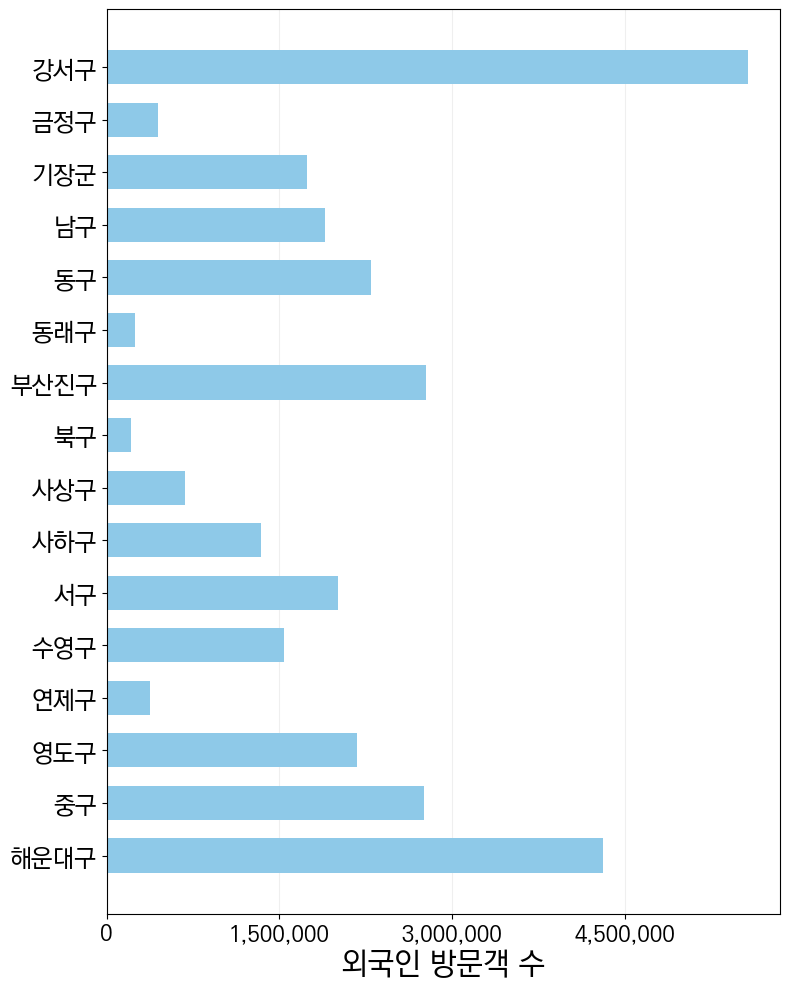

In [55]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    local_2025['구군'],
    local_2025['외국인'],
    color='#8EC9E8',
    height=0.65
)

# 가나다순 위 → 아래
ax.invert_yaxis()

# 축 설정
ax.set_xlabel(
    '외국인 방문객 수',
    fontsize=22,
    fontweight='bold'
)
ax.set_ylabel('')

# 틱 라벨
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=18)

# x축 틱 간격 넓게: 200만 단위
ax.xaxis.set_major_locator(
    MultipleLocator(1_500_000)
)

# 숫자 콤마 표시
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# 보조선
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    '2025_구군별_외국인.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

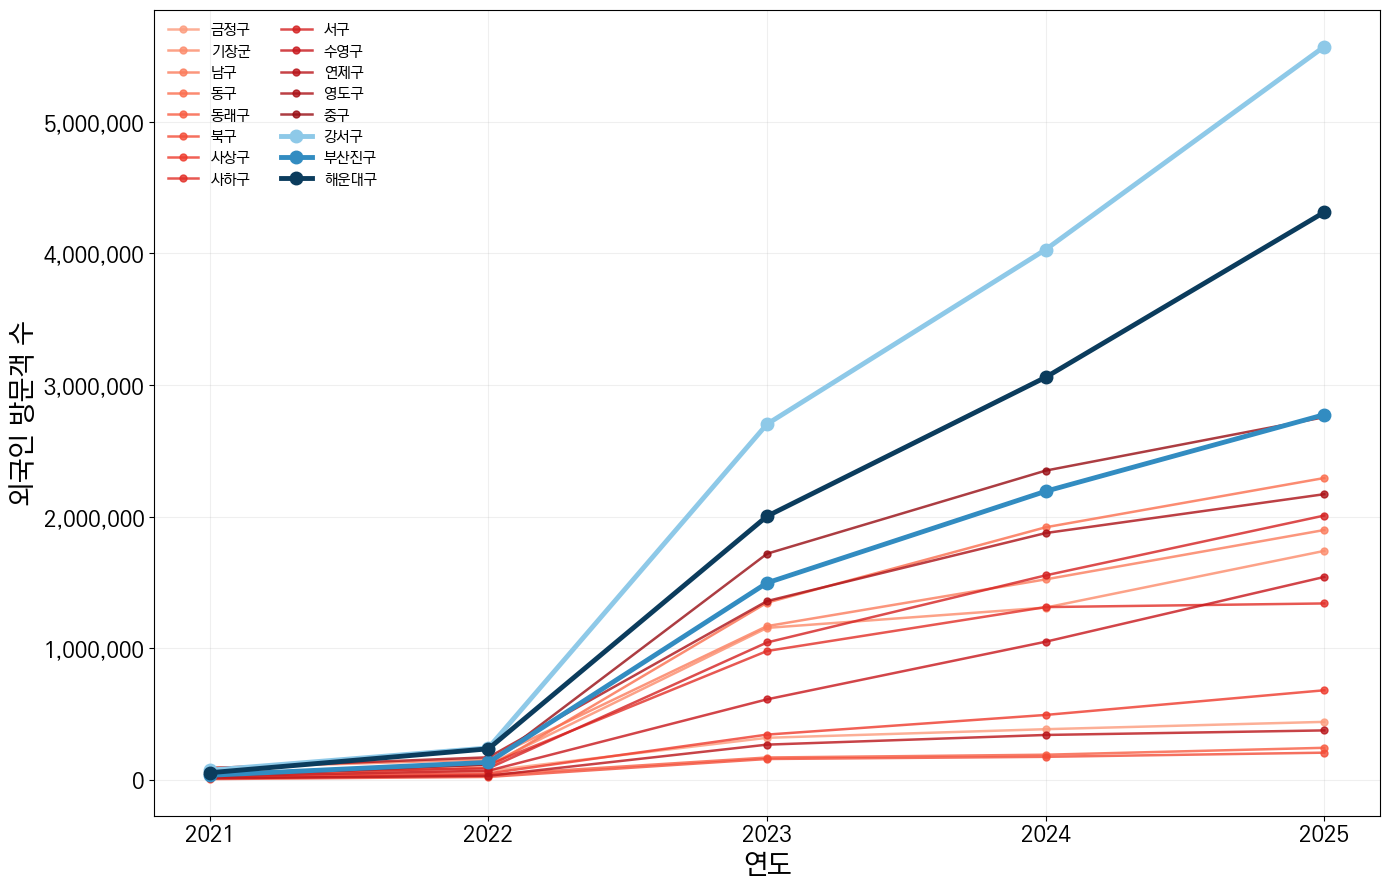

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 9))

# 강조할 3개 구
main_gu = ['강서구', '부산진구', '해운대구']

# 파란 계열
blue_colors = {
    '강서구': '#8EC9E8',
    '부산진구': '#328CC1',
    '해운대구': '#0B3C5D'
}

# 전체 구군
gu_list = sorted(df['구군'].unique())

# 나머지 구군
other_gu = [gu for gu in gu_list if gu not in main_gu]

# 붉은 계열
cmap = plt.cm.Reds
red_colors = [
    cmap(0.35 + 0.55 * i / max(len(other_gu) - 1, 1))
    for i in range(len(other_gu))
]

# -----------------------
# 나머지 구군 → 붉은 계열
# -----------------------
for gu, color in zip(other_gu, red_colors):

    temp = (
        df[df['구군'] == gu]
        .sort_values('연도')
    )

    ax.plot(
        temp['연도'],
        temp['외국인'],
        marker='o',
        markersize=5,
        linewidth=1.8,
        color=color,
        label=gu,
        alpha=0.8
    )

# -----------------------
# 주요 3개 구 → 파란 계열
# -----------------------
for gu in main_gu:

    temp = (
        df[df['구군'] == gu]
        .sort_values('연도')
    )

    ax.plot(
        temp['연도'],
        temp['외국인'],
        marker='o',
        markersize=9,
        linewidth=3.5,
        color=blue_colors[gu],
        label=gu,
        zorder=10
    )

# x축
ax.set_xticks([2021, 2022, 2023, 2024, 2025])

ax.set_xlabel(
    '연도',
    fontsize=20,
    fontweight='bold'
)

ax.set_ylabel(
    '외국인 방문객 수',
    fontsize=20,
    fontweight='bold'
)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# y축 콤마
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# 범례
ax.legend(
    fontsize=11,
    ncol=2,
    frameon=False
)

# 보조선
ax.grid(
    axis='both',
    alpha=0.2
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    '전체구군_외국인_시계열.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

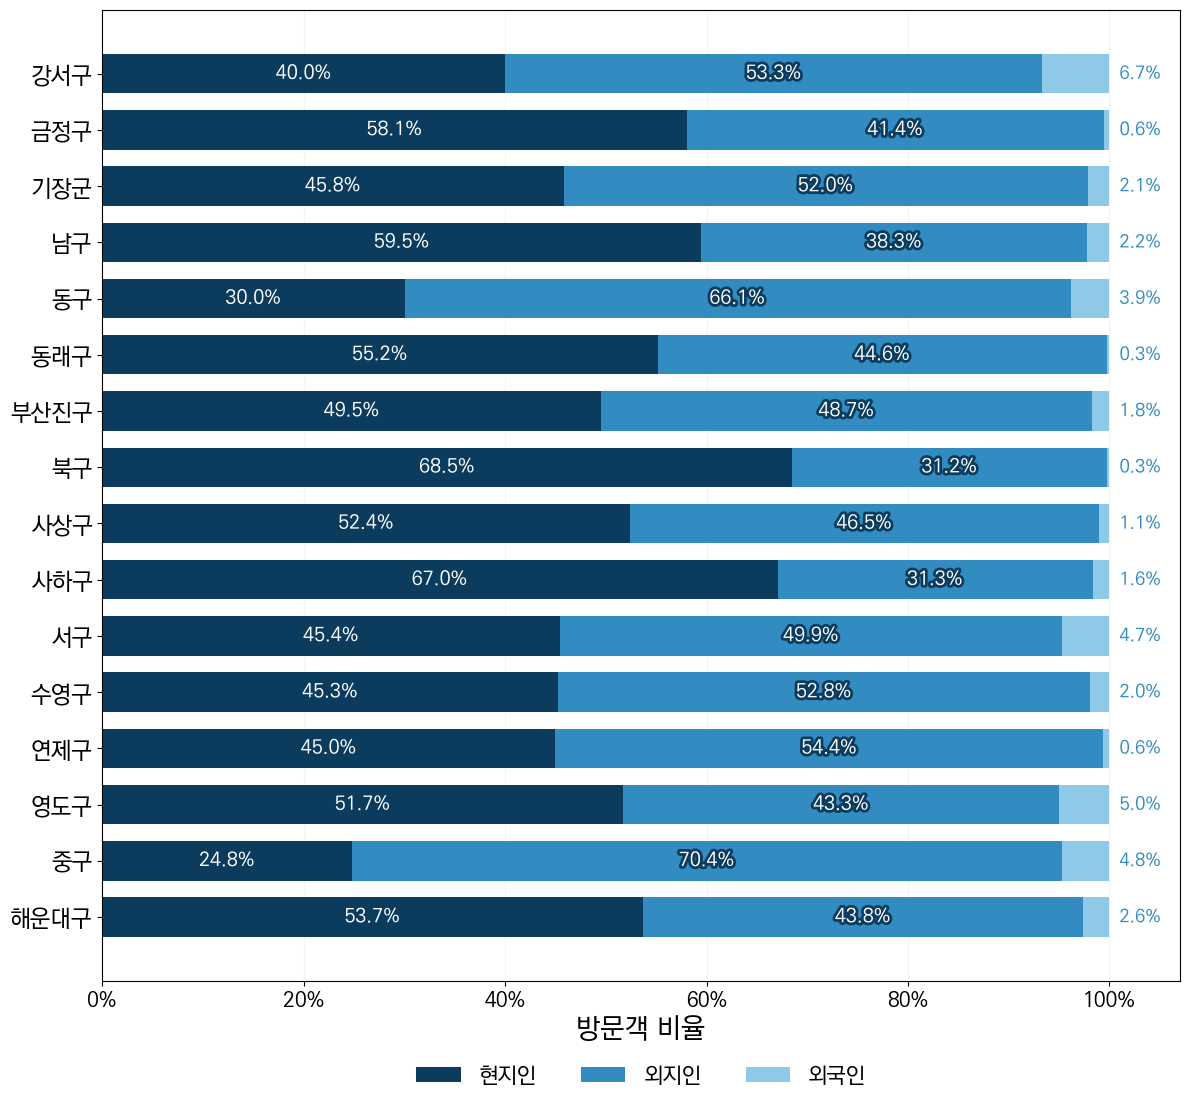

In [63]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import PercentFormatter

# 2025년 데이터
plot_df = (
    df[df['연도'] == 2025]
    .sort_values('구군')
    .reset_index(drop=True)
    .copy()
)

# 전체 및 비율 계산
plot_df['전체'] = (
    plot_df['현지인']
    + plot_df['외지인']
    + plot_df['외국인']
)

plot_df['현지인_pct'] = plot_df['현지인'] / plot_df['전체'] * 100
plot_df['외지인_pct'] = plot_df['외지인'] / plot_df['전체'] * 100
plot_df['외국인_pct'] = plot_df['외국인'] / plot_df['전체'] * 100


# 그래프
fig, ax = plt.subplots(figsize=(12, 11))

colors = {
    '현지인': '#0B3C5D',
    '외지인': '#328CC1',
    '외국인': '#8EC9E8'
}

# 누적 막대
ax.barh(
    plot_df['구군'],
    plot_df['현지인_pct'],
    color=colors['현지인'],
    label='현지인',
    height=0.7
)

ax.barh(
    plot_df['구군'],
    plot_df['외지인_pct'],
    left=plot_df['현지인_pct'],
    color=colors['외지인'],
    label='외지인',
    height=0.7
)

ax.barh(
    plot_df['구군'],
    plot_df['외국인_pct'],
    left=plot_df['현지인_pct'] + plot_df['외지인_pct'],
    color=colors['외국인'],
    label='외국인',
    height=0.7
)


# 네온 느낌 텍스트 효과
neon_effect = [
    pe.Stroke(linewidth=4, foreground='#0B3C5D'),
    pe.Normal()
]


# 비율 레이블
for i in range(len(plot_df)):

    local = plot_df.loc[i, '현지인_pct']
    domestic = plot_df.loc[i, '외지인_pct']
    foreign = plot_df.loc[i, '외국인_pct']

    # 현지인
    ax.text(
        local / 2,
        i,
        f'{local:.1f}%',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='white',
        path_effects=neon_effect
    )

    # 외지인
    ax.text(
        local + domestic / 2,
        i,
        f'{domestic:.1f}%',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='white',
        path_effects=neon_effect
    )

    # 외국인 - 오른쪽 바깥
    ax.text(
        101,
        i,
        f'{foreign:.1f}%',
        ha='left',
        va='center',
        fontsize=13,
        fontweight='bold',
        color='#328CC1',
        path_effects=[
            pe.Stroke(linewidth=3, foreground='white'),
            pe.Normal()
        ]
    )


# 가나다순
ax.invert_yaxis()

# 축 설정
ax.set_xlim(0, 107)
ax.set_xlabel(
    '방문객 비율',
    fontsize=20,
    fontweight='bold'
)
ax.set_ylabel('')

ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.xaxis.set_major_formatter(PercentFormatter(100))

ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=17)

# 범례
ax.legend(
    fontsize=16,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.13),
    ncol=3
)

ax.grid(axis='x', alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    '2025_구군별_방문객_구성비.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()